In [3]:
# ==============================================================================
# PROJETO: Classificação de Riscos e Estimativa de Eventos Climáticos Extremos
# ETAPAS: Pré-processamento, Treinamento (Regressão Logística, KNN, Regressão Linear/Múltipla/Polinomial)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Para Classificação (Categorização do Nível de Risco: Baixo, Médio, Alto)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. Para Regressão (Estimativa da População Afetada)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [4]:
# ==============================================================================
# 1.5.2. PRÉ-PROCESSAMENTO E FEATURE ENGINEERING
# ==============================================================================

try:
    df = pd.read_excel('Danos_Informados.xlsx')
except FileNotFoundError:
    print("⚠️ Arquivo 'Danos_Informados.xlsx' não encontrado no ambiente do Colab.")

# Removendo duplicadas e limpando inconsistências
df = df.drop_duplicates().reset_index(drop=True)
df['UF'] = df['UF'].astype(str).str.upper().str.strip()

inconsistentes = df['DH_Mortos'] > df['População']
if inconsistentes.sum() > 0:
    df.loc[inconsistentes, 'DH_Mortos'] = df.loc[inconsistentes, 'População']

# b) Tratamento de Nulos
# Preenchendo colunas numéricas de contagem usadas na lógica com 0
colunas_contagem = ['DH_Mortos', 'DH_Desabrigados', 'DH_Desalojados', 'DH_Feridos',
                    'DH_Enfermos', 'DH_Desaparecidos', 'DH_Outros Afetados']

for col in colunas_contagem:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Preenchendo População com a mediana se houver nulos
if 'População' in df.columns and df['População'].isnull().sum() > 0:
    df['População'] = df['População'].fillna(df['População'].median())

colunas_ambientais = [col for col in df.columns if col.startswith('DA_')]
for col in colunas_ambientais:
    df[col] = df[col].fillna('Não Informado').astype(str)

# e) Engenharia de Atributos
df['DH_Total_Direto'] = df[['DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados', 'DH_Desalojados', 'DH_Desaparecidos']].sum(axis=1)
df['População_Afetada_Total'] = df['DH_Total_Direto'] + df['DH_Outros Afetados']

col_mat = [col for col in df.columns if col.startswith('DM_') and 'Valor' in col]
col_pub = [col for col in df.columns if col.startswith('PEPL_')]
col_priv = [col for col in df.columns if col.startswith('PEPR_')]
df['Prejuizo_Financeiro_Total'] = df[col_mat + col_pub + col_priv].sum(axis=1)

# Definição do Alvo de Classificação
def categorizar_risco(row):
    if row['DH_Mortos'] > 0 or row['DH_Desabrigados'] > 100 or row['População_Afetada_Total'] > 5000:
        return 'Alto'
    elif row['DH_Desalojados'] > 20 or row['População_Afetada_Total'] > 500:
        return 'Médio'
    else:
        return 'Baixo'

df['Nivel_Risco'] = df.apply(categorizar_risco, axis=1)

# Extrai a categoria legível do evento a partir do código COBRADE
# Ex: "13214 - Tempestade Local/Convectiva - Chuvas Intensas" -> "Tempestade Local/Convectiva"
df['Tipo_Evento'] = df['COBRADE'].astype(str).str.split(' - ').str[1].fillna('Outros').str.strip()

features_para_remover = [
    'Registro', 'Protocolo', 'Município', 'Status', 'Nivel_Risco', 'COBRADE',
    'População_Afetada_Total', 'DH_Total_Direto',
    'DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados',
    'DH_Desalojados', 'DH_Desaparecidos', 'DH_Outros Afetados',
    'Prejuizo_Financeiro_Total'
]

X = df.drop(columns=[col for col in features_para_remover if col in df.columns])

# Alvo 1: Classificação (Nivel_Risco)
y_class = LabelEncoder().fit_transform(df['Nivel_Risco'])

# Alvo 2: Regressão (População_Afetada_Total)
y_reg = df['População_Afetada_Total']

# a) Divisão de Dados (70% Treino, 15% Validação, 15% Teste)
X_train, X_temp, y_train_cls, y_temp_cls, y_train_reg, y_temp_reg = train_test_split(
    X, y_class, y_reg, test_size=0.30, random_state=42, stratify=y_class
)
X_val, X_test, y_val_cls, y_test_cls, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_cls, y_temp_reg, test_size=0.50, random_state=42, stratify=y_temp_cls
)

# c) e d) Encoding e StandardScaler
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("✅ Pré-processamento concluído com sucesso!")

✅ Pré-processamento concluído com sucesso!


In [5]:
# ==============================================================================
# CÁLCULO DOS CORTES DE RISCO (REGRA BASEADA EM PERCENTUAL)
# Calculado apenas sobre o TREINO, para não vazar informação do teste
# ==============================================================================

percentual_treino = (y_train_reg / X_train['População']) * 100
percentual_treino = percentual_treino.replace([np.inf, -np.inf], np.nan).dropna()

print("=== DISTRIBUIÇÃO DO PERCENTUAL DE POPULAÇÃO AFETADA (TREINO) ===")
print(percentual_treino.describe())
print(percentual_treino.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

# Diagnóstico do platô em 100% (registros onde população_afetada = população_total)
n_travados_100 = (percentual_treino >= 100).sum()
pct_travados_100 = (percentual_treino >= 100).mean() * 100
n_acima_100 = (percentual_treino > 100).sum()

print(f"\n⚠️ Registros com percentual >= 100%: {n_travados_100} ({pct_travados_100:.2f}% da base de treino)")
print(f"⚠️ Registros com percentual > 100% (fisicamente impossíveis): {n_acima_100}")

# Cortes finais
# P90 fica contaminado pelo platô de 100% (ver diagnóstico acima) -> usamos P75 como corte Alto
corte_medio = percentual_treino.quantile(0.5)   # Mediana -> corte Baixo/Médio
corte_alto = percentual_treino.quantile(0.75)   # P75 -> corte Médio/Alto (em vez de P90)

print(f"\n👉 Corte Baixo/Médio (mediana): {corte_medio:.4f}%")
print(f"👉 Corte Médio/Alto (P75, ajustado pelo platô em 100%): {corte_alto:.4f}%")

=== DISTRIBUIÇÃO DO PERCENTUAL DE POPULAÇÃO AFETADA (TREINO) ===
count    4220.000000
mean       28.521591
std        46.152053
min         0.000000
25%         0.000000
50%         3.603396
75%        50.160332
max      1374.134663
dtype: float64
0.50      3.603396
0.75     50.160332
0.90    100.000000
0.95    100.000000
0.99    119.053467
dtype: float64

⚠️ Registros com percentual >= 100%: 482 (11.42% da base de treino)
⚠️ Registros com percentual > 100% (fisicamente impossíveis): 205

👉 Corte Baixo/Médio (mediana): 3.6034%
👉 Corte Médio/Alto (P75, ajustado pelo platô em 100%): 50.1603%



--- TREINANDO MODELOS DE REGRESSÃO ---
👉 Melhor parâmetro KNN Regressor: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

=== TABELA DE MÉTRICAS - REGRESSÃO ===


,Modelo de Regressão,MAE (Erro Absoluto Médio),RMSE (Raiz do Erro Quadrático Médio),R² (Coeficiente de Determinação)
0,Regressão Múltipla,14771.32,82029.60,0.3883
1,KNN Regressor (K=3),6592.66,32808.38,0.9021


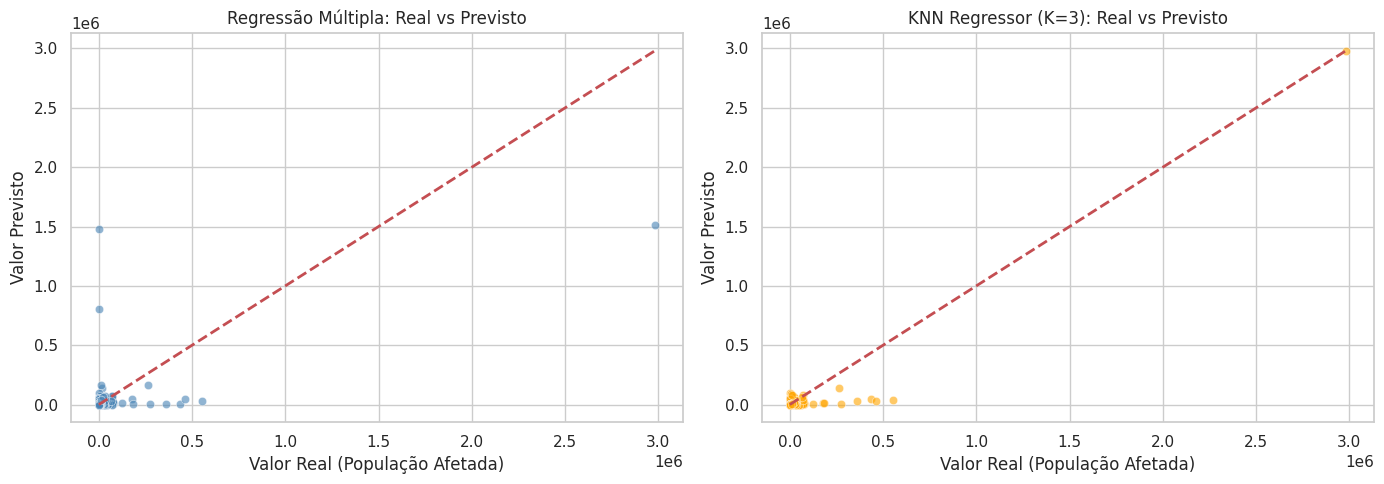

In [6]:
# ==============================================================================
# PARTE 2: ABORDAGEM DE REGRESSÃO (KNN Regressor + Regressão Múltipla)
# Modelos Utilizados: KNN Regressor (Aula 08) e Regressão Múltipla (Aula 06)
# ==============================================================================

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

print("\n--- TREINANDO MODELOS DE REGRESSÃO ---")

# 1. Regressão Múltipla
reg_multipla = LinearRegression()
reg_multipla.fit(X_train_prep, y_train_reg)
y_pred_multipla = np.maximum(0, reg_multipla.predict(X_test_prep))

# 2. KNN Regressor com Otimização de Hiperparâmetros
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_knn_reg.fit(X_train_prep, y_train_reg)

# Melhor modelo KNN encontrado
best_knn_reg = grid_knn_reg.best_estimator_
y_pred_knn = np.maximum(0, best_knn_reg.predict(X_test_prep))

print(f"👉 Melhor parâmetro KNN Regressor: {grid_knn_reg.best_params_}")

# Tabela de Métricas
def metricas_reg(y_true, y_pred, nome):
    return {
        'Modelo de Regressão': nome,
        'MAE (Erro Absoluto Médio)': f"{mean_absolute_error(y_true, y_pred):.2f}",
        'RMSE (Raiz do Erro Quadrático Médio)': f"{np.sqrt(mean_squared_error(y_true, y_pred)):.2f}",
        'R² (Coeficiente de Determinação)': f"{r2_score(y_true, y_pred):.4f}"
    }

df_res_reg = pd.DataFrame([
    metricas_reg(y_test_reg, y_pred_multipla, "Regressão Múltipla"),
    metricas_reg(y_test_reg, y_pred_knn, f"KNN Regressor (K={grid_knn_reg.best_params_['n_neighbors']})")
])

print("\n=== TABELA DE MÉTRICAS - REGRESSÃO ===")
display(df_res_reg)

# Gráficos de Dispersão: Real vs Previsto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definindo limite máximo para a linha de referência perfeita (y = x)
max_val = max(y_test_reg.max(), max(y_pred_multipla.max(), y_pred_knn.max()))

# 1. Gráfico Regressão Múltipla
sns.scatterplot(x=y_test_reg, y=y_pred_multipla, ax=axes[0], alpha=0.6, color='steelblue')
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)  # Linha de identidade (y=x)
axes[0].set_title('Regressão Múltipla: Real vs Previsto')
axes[0].set_xlabel('Valor Real (População Afetada)')
axes[0].set_ylabel('Valor Previsto')

# 2. Gráfico KNN Regressor
sns.scatterplot(x=y_test_reg, y=y_pred_knn, ax=axes[1], alpha=0.6, color='orange')
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)  # Linha de identidade (y=x)
axes[1].set_title(f"KNN Regressor (K={grid_knn_reg.best_params_['n_neighbors']}): Real vs Previsto")
axes[1].set_xlabel('Valor Real (População Afetada)')
axes[1].set_ylabel('Valor Previsto')

plt.tight_layout()
plt.show()

In [7]:
# Criar um DataFrame de inspeção no conjunto de teste com o nome da cidade
df_outliers = pd.DataFrame({
    'Cidade': df.loc[X_test.index, 'Município'],
    'Valor_Real': y_test_reg,
    'Predito_Reg_Multipla': y_pred_multipla,
    'Erro_Abs_Multipla': np.abs(y_test_reg - y_pred_multipla),
    'Predito_KNN': y_pred_knn,
    'Erro_Abs_KNN': np.abs(y_test_reg - y_pred_knn)
})

# 1. Registro com o maior valor real (o ponto isolado na extrema direita do gráfico)
print("=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===")
maior_real = df_outliers.sort_values(by='Valor_Real', ascending=False).head(1)
display(maior_real)

# 2. Os 5 maiores erros de previsão na Regressão Múltipla
print("\n=== TOP 5 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===")
display(df_outliers.sort_values(by='Erro_Abs_Multipla', ascending=False).head(5))

# 3. Os 5 maiores erros de previsão no KNN Regressor
print("\n=== TOP 5 MAIORES DISCREPÂNCIAS (KNN Regressor) ===")
display(df_outliers.sort_values(by='Erro_Abs_KNN', ascending=False).head(5))

=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
3088,Brasília,2982818.0,1.514635e+06,1.468183e+06,2982818.0,0.0



=== TOP 5 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
3248,Brasília,0.0,1.481521e+06,1.481521e+06,0.000000e+00,0.000000
3088,Brasília,2982818.0,1.514635e+06,1.468183e+06,2.982818e+06,0.000000
261,Campo Largo,100.0,8.016982e+05,8.015982e+05,5.478325e+01,45.216754
1895,Cuiabá,551350.0,3.157104e+04,5.197790e+05,3.641434e+04,514935.659268
3661,Caxias do Sul,435482.0,7.739031e+03,4.277430e+05,4.332747e+04,392154.533547



=== TOP 5 MAIORES DISCREPÂNCIAS (KNN Regressor) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
1895,Cuiabá,551350.0,31571.039683,519778.960317,36414.340732,514935.659268
2048,Porto Velho,460000.0,46349.865291,413650.134709,29818.580276,430181.419724
3661,Caxias do Sul,435482.0,7739.030600,427742.969400,43327.466453,392154.533547
2616,Quixeramobim,360000.0,6904.358070,353095.641930,31226.419149,328773.580851
4483,Santa Maria,271730.0,7374.618495,264355.381505,8158.601451,263571.398549


In [8]:
# ==============================================================================
# SALVAR MODELO DE REGRESSÃO E PREPROCESSOR
# ==============================================================================

import joblib
from google.colab import files

print("📦 Exportando o modelo de regressão e o preprocessor...")

# 1. Salvar Modelo de Regressão (KNN Regressor)
modelo_regressao = grid_knn_reg.best_estimator_ if 'grid_knn_reg' in globals() else best_knn_reg
joblib.dump(modelo_regressao, 'modelo_1_regressao_knn.pkl')

# 2. Salvar o Preprocessor (ColumnTransformer)
joblib.dump(preprocessor, 'preprocessor.pkl')

import sklearn, numpy, joblib as jl; print(sklearn.__version__, numpy.__version__, jl.__version__)

# 3. Baixar os arquivos .pkl no navegador
files.download('modelo_1_regressao_knn.pkl')
files.download('preprocessor.pkl')

print("✅ Download do modelo e do preprocessor iniciado com sucesso!")
print(f"👉 Use estes cortes no app.py: Baixo/Médio = {corte_medio:.4f}%  |  Médio/Alto = {corte_alto:.4f}%")

📦 Exportando o modelo de regressão e o preprocessor...
1.6.1 2.1.3 1.6.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download do modelo e do preprocessor iniciado com sucesso!
👉 Use estes cortes no app.py: Baixo/Médio = 3.6034%  |  Médio/Alto = 50.1603%
